In [1]:
import gymnasium as gym
import numpy as np
import cv2
import ale_py

from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage, VecFrameStack, SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.atari_wrappers import FireResetEnv

In [2]:
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import glob
from datetime import datetime

In [3]:
gym.register_envs(ale_py)

In [4]:
log_dir = "./logs_breakout/"
os.makedirs(log_dir, exist_ok=True)

In [5]:
class WhitePatchBreakout(gym.Wrapper):
    def __init__(self, env, apply_patch=False, region=(20, 40, 30, 30)):
        super().__init__(env)
        self.apply_patch = apply_patch
        self.x, self.y, self.w, self.h = region

    def _paint_patch(self, img):
        if not self.apply_patch:
            return img
        
        # Copia para não alterar o buffer original inadvertidamente
        img = img.copy()
        
        # Detecta dimensões (pode ser 84x84 ou a resolução nativa no render)
        H, W = img.shape[:2]
        
        x, y, w, h = self.x, self.y, self.w, self.h
        
        # Garante que o desenho não exceda as bordas
        y_end = min(y + h, H)
        x_end = min(x + w, W)
        
        if y < y_end and x < x_end:
            # Pinta de branco (255). Funciona tanto para RGB quanto Grayscale se ajustado
            img[y:y_end, x:x_end] = 255
            
        return img

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._paint_patch(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._paint_patch(obs), reward, terminated, truncated, info

    def render(self):
        # Mágica para o vídeo: Pega o render original e aplica a mancha nele
        img = self.env.render()
        return self._paint_patch(img)

In [6]:
class BlurBreakout(gym.Wrapper):
    def __init__(self, env, apply_blur=False, region=(20, 40, 30, 30), ksize=21):
        super().__init__(env)
        self.apply_blur = apply_blur
        self.x, self.y, self.w, self.h = region
        self.ksize = ksize if ksize % 2 == 1 else ksize + 1

    def _apply_blur(self, img):
        if not self.apply_blur:
            return img
        
        img = img.copy()
        H, W = img.shape[:2]
        x, y, w, h = self.x, self.y, self.w, self.h
        
        y_end = min(y + h, H)
        x_end = min(x + w, W)
        
        if y < y_end and x < x_end:
            roi = img[y:y_end, x:x_end]
            # Aplica Gaussian Blur na região de interesse
            blurred_roi = cv2.GaussianBlur(roi, (self.ksize, self.ksize), 0)
            img[y:y_end, x:x_end] = blurred_roi
            
        return img

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._apply_blur(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._apply_blur(obs), reward, terminated, truncated, info
    
    def render(self):
        img = self.env.render()
        return self._apply_blur(img)

In [7]:
class GrayscaleWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        # Força explicitamente o shape (H, W, 1) para compatibilidade com SB3
        old_shape = self.observation_space.shape
        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=(old_shape[0], old_shape[1], 1), dtype=np.uint8
        )

    def _convert(self, obs):
        # Se for RGB (3 canais), converte para Gray e mantém dimensão extra
        if obs.ndim == 3 and obs.shape[2] == 3:
            return cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)[:, :, None]
        return obs

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._convert(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._convert(obs), reward, terminated, truncated, info

In [8]:
def _create_base_gym_env(render_mode, with_modification, modification_type, log_dir=None):
    """
    Função interna para garantir que a ordem dos wrappers seja idêntica
    tanto no treino quanto no vídeo.
    """
    env = gym.make("ALE/Breakout-v5", render_mode=render_mode)
    
    # 1. Garante inicio do jogo
    env = FireResetEnv(env)
    
    # 2. Resize para 84x84 (Colorido)
    # façam sentido na imagem pequena.
    env = gym.wrappers.ResizeObservation(env, (84, 84))
    
    # 3. Aplica a Modificação Visual (Blur ou White Patch)
    if modification_type == 'white_patch':
        env = WhitePatchBreakout(env, apply_patch=with_modification, region=(20, 40, 30, 30))
    elif modification_type == 'blur':
        env = BlurBreakout(env, apply_blur=with_modification, region=(20, 40, 30, 30), ksize=21)
    

    if log_dir:
        env = Monitor(env, log_dir)
        
    return env

In [9]:
def make_training_env(with_blur=False, change='white_patch', log_dir="./logs/"):
    """
    Cria o ambiente de treino.
    Agora gera um arquivo monitor com TIMESTAMP para não sobrescrever os anteriores.
    Ex: ./logs/monitor_20231027_153000.csv
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)
    
    # Gera o timestamp UMA VEZ para este ambiente
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    def _init():
        # 1. Base Environment
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        
        # 2. Fire Reset
        env = FireResetEnv(env)
        
        # 3. Resize PRIMEIRO (Para 84x84)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # 4. Aplica a Modificação (Blur ou White Patch)
        if change == 'white_patch':
            # Usa sua classe com apply_patch=with_blur
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=(20, 40, 30, 30))
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=(20, 40, 30, 30), ksize=21)
        
        # 5. Grayscale (Transforma em H, W, 1)
        env = GrayscaleWrapper(env)
        
        # 6. Monitor (AGORA COM TIMESTAMP NO NOME)
        if log_dir:
            # Cria o caminho: ./logs/monitor_20231123_220000
            # O SB3 adiciona .csv automaticamente na maioria das versões
            filename = os.path.join(log_dir, f"monitor_{timestamp}")
            env = Monitor(env, filename)
            
        return env

    # 7. Vetorização (SB3)
    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    
    return env

In [10]:
def make_training_env(with_blur=False, change='white_patch', log_dir="./logs/"):
    """
    Cria o ambiente de treino mantendo a consistência exata com o ambiente de avaliação.
    Parâmetros renomeados para bater com sua chamada: with_blur, change.
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)

    def _init():
        # 1. Base Environment
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        
        # 2. Fire Reset
        env = FireResetEnv(env)
        
        # 3. Resize PRIMEIRO (Para 84x84)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # 4. Aplica a Modificação (Blur ou White Patch)
        if change == 'white_patch':
            # Usa sua classe com apply_patch=with_blur
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=(20, 40, 30, 30))
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=(20, 40, 30, 30), ksize=21)
        
        # 5. Grayscale (Transforma em H, W, 1)
        env = GrayscaleWrapper(env)
        
        # 6. Monitor
        if log_dir:
            env = Monitor(env, log_dir)
            
        return env

    # 7. Vetorização (SB3)
    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    
    return env

In [11]:
def make_training_env(with_blur=False, change='white_patch', zone='middle', log_dir="./logs/"):
    """
    Cria ambiente com zonas configuráveis.
    Zonas disponíveis: 'top', 'middle', 'bottom'.
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)

    # Coordenadas fixas para 84x84 (Mantendo mancha de 30x30)
    # X=27 centraliza horizontalmente (84 - 30) / 2
    presets = {
        # ZONA 1: TOP (TIJOLOS)
        # Y=18 estava alto. Vamos para Y=24.
        # X=25 corrige o deslocamento para a esquerda.
        'top':    (60, 55, 40, 40), 

        # ZONA 2: MIDDLE (TRAJETÓRIA/REAÇÃO)
        # Y=40 cobre a área onde a bola corre antes de chegar no paddle.
        # Fica logo abaixo da massa principal de tijolos.
        'middle': (60, 110, 40, 40), 

        # ZONA 3: BOTTOM (PADDLE)
        # Y=44 garante que a mancha vá até o pixel 84 (fim da tela).
        # Cobre totalmente a área de movimento do paddle.
        'bottom': (60, 165, 40, 40)  
    }
    
    # Seleciona a região baseada no nome, ou usa 'middle' como padrão
    region = presets.get(zone, (27, 40, 30, 30))

    def _init():
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        env = FireResetEnv(env)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # Aplica a mancha na zona escolhida
        if change == 'white_patch':
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=region)
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=region, ksize=21)
        
        env = GrayscaleWrapper(env)
        
        if log_dir:
            # Adiciona o nome da zona no log para diferenciar depois
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = os.path.join(log_dir, f"monitor_{zone}_{timestamp}")
            env = Monitor(env, filename)
            
        return env

    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    
    return env

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


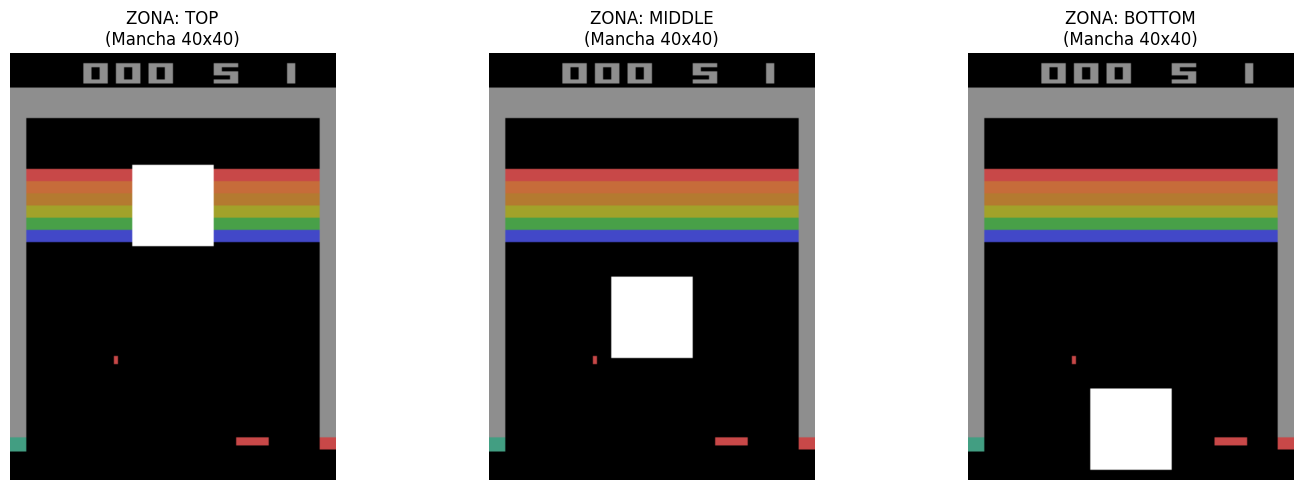

In [12]:
def debug_visualize_zones():
    zones = ['top', 'middle', 'bottom']
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for i, zone in enumerate(zones):
        # Cria ambiente temporário
        env = make_training_env(with_blur=True, change='white_patch', zone=zone, log_dir=None)
        
        env.reset()
        # Dá alguns passos para o jogo começar e a bola aparecer (se possível)
        for _ in range(5):
            obs, _, _, _ = env.step([1]) # Fire/Noop
            
        # Pega o render colorido interno (O que nós vemos)
        # O env é um VecEnv, então acessamos envs[0]
        img = env.envs[0].render()
        
        axes[i].imshow(img)
        axes[i].set_title(f"ZONA: {zone.upper()}\n(Mancha 40x40)")
        axes[i].axis('off')
        
        env.close()
    
    plt.tight_layout()
    plt.show()

# RODE ISSO AGORA:
debug_visualize_zones()

In [13]:
def make_training_env(with_blur=False, change='white_patch', zone='middle', log_dir="./logs/"):
    """
    Cria ambiente com zonas configuráveis.
    Zonas disponíveis: 'top', 'middle', 'bottom'.
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)

    # --- CORREÇÃO DE ESCALA ---
    # A imagem da IA tem apenas 84x84 pixels.
    # Tamanho da Mancha: 40x40 pixels.
    # Centralização X: (84 - 40) / 2 = 22.
    
    presets = {
        # ZONA 1: TOP (TIJOLOS)
        # Y=25: Centraliza a mancha na massa de tijolos coloridos.
        'top':    (32, 25, 20, 20), 

        # ZONA 2: MIDDLE (TRAJETÓRIA)
        # Y=50: Fica no espaço vazio logo acima da linha de perigo.
        'middle': (32, 50, 20, 20), 

        # ZONA 3: BOTTOM (PADDLE)
        # Y=64: Vai exatamente até o pixel 84 (64+20=84).
        # Cobre apenas o centro do paddle, exigindo precisão.
        'bottom': (32, 64, 20, 20)  
    }
    
    region = presets.get(zone, (22, 38, 40, 40))

    def _init():
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        env = FireResetEnv(env)
        
        # 1. Redimensiona PRIMEIRO (O mundo vira 84x84 aqui)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # 2. Aplica a Mancha DEPOIS (Usando as coordenadas convertidas acima)
        if change == 'white_patch':
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=region)
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=region, ksize=21)
        
        env = GrayscaleWrapper(env)
        
        if log_dir:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = os.path.join(log_dir, f"monitor_{zone}_{timestamp}")
            env = Monitor(env, filename)
            
        return env

    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    
    return env

Gerando visualização para a zona: top...
Gerando visualização para a zona: middle...
Gerando visualização para a zona: bottom...


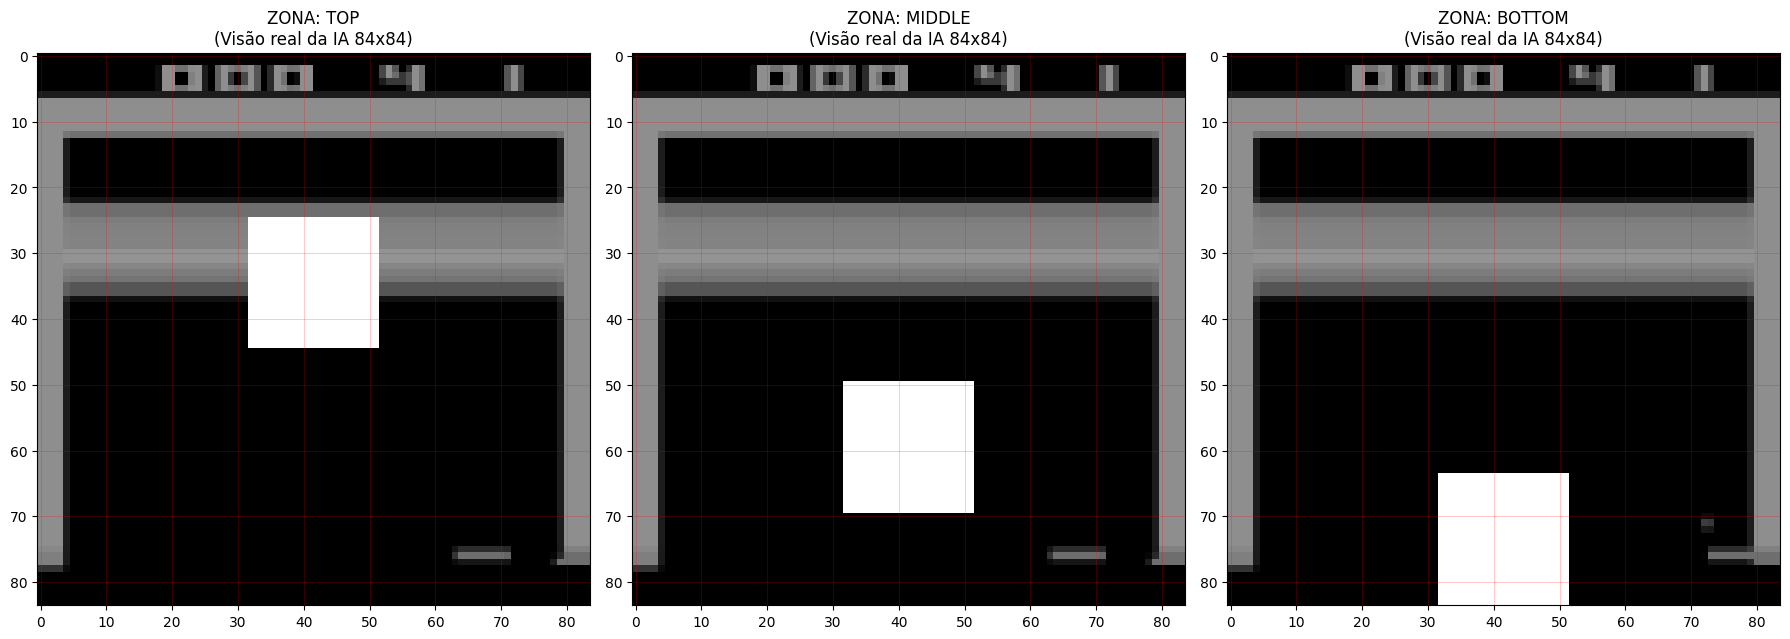

In [14]:
def visualize_agent_view():
    zones = ['top', 'middle', 'bottom']
    
    # Cria uma figura com 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, zone in enumerate(zones):
        print(f"Gerando visualização para a zona: {zone}...")
        
        # 1. Cria o ambiente com a zona específica
        # (Usa a função make_training_env que acabamos de corrigir)
        env = make_training_env(with_blur=True, change='white_patch', zone=zone, log_dir=None)
        
        obs = env.reset()
        
        # 2. Avança o jogo por 40 passos para garantir que:
        # - O jogo começou (FIRE)
        # - Os tijolos desceram (se for o caso)
        # - A bola apareceu
        for _ in range(40):
            # Envia ação 1 (FIRE) para iniciar, depois aleatório ou NOOP
            action = [1] 
            obs, _, _, _ = env.step(action)
            
        # 3. Extrai a imagem
        # O shape do obs é (1, 4, 84, 84) -> (Batch, Channels/Stack, Height, Width)
        # Pegamos o índice [0, 3, :, :] -> O último frame empilhado (o mais atual)
        frame_atual = obs[0, 3, :, :]
        
        # 4. Plota
        ax = axes[i]
        ax.imshow(frame_atual, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f"ZONA: {zone.upper()}\n(Visão real da IA 84x84)", fontsize=12)
        
        # Adiciona linhas de grade para ajudar a contar pixels (opcional)
        ax.grid(color='red', linestyle='-', linewidth=0.5, alpha=0.3)
        ax.set_xticks(np.arange(0, 84, 10))
        ax.set_yticks(np.arange(0, 84, 10))
        
        env.close()

    plt.tight_layout()
    plt.show()

# Execute agora:
visualize_agent_view()

In [15]:
steps = 3_000_000

In [16]:
# DQN("CnnPolicy", 
#     env_blur, 
#     verbose=1,buffer_size=100_000,  
#     optimize_memory_usage=False,
#     learning_starts=50_000,
#     learning_rate=1e-4,
#     batch_size=32,
#     exploration_fraction=0.1,
#     exploration_final_eps=0.01,
#     train_freq=4,
#     target_update_interval=100,
#     gradient_steps=1,
#     tensorboard_log="./tensorboard_logs/")

In [17]:
# model_blur = DQN(
#     "CnnPolicy", 
#     env_blur, 
#     verbose=1, 
    
#     # 1. Memória (Buffer)
#     # Aumentar permite que o agente lembre de experiências mais antigas e variadas.
#     # Se der erro de memória RAM, diminua para 50_000 ou ative optimize_memory_usage=True
#     buffer_size=100_000,  
#     optimize_memory_usage=False, 

#     # 2. Quando começar a aprender
#     # Espere o buffer encher bastante antes de começar a atualizar os pesos.
#     # Isso evita overfitting em movimentos aleatórios iniciais.
#     learning_starts=50_000, 

#     # 3. Taxa de Aprendizado (Padrão Atari)
#     learning_rate=1e-4, 

#     # 4. Batch Size
#     # 32 é o clássico para Atari.
#     batch_size=32, 

#     # 5. Exploração (Epsilon-Greedy)
#     # exploration_fraction: Fração do total_timesteps que ele passa diminuindo a exploração.
#     # 0.1 (10%) de 1M steps = 100k steps explorando muito. 
#     exploration_fraction=0.1, 
#     # exploration_final_eps: No final, 1% de chance de movimento aleatório é melhor que 5% no Breakout.
#     exploration_final_eps=0.01, 

#     # 6. Frequência de Treino
#     # Treina a cada 4 passos do ambiente (Padrão do artigo Nature).
#     train_freq=4, 
    
#     # 7. Atualização da Rede Alvo (Estabilidade)
#     # A cada 1000 passos, copia os pesos para a rede alvo.
#     target_update_interval=1000, 
    
#     # 8. Gradiente
#     gradient_steps=1,
    
#     # (Opcional) Logs para Tensorboard (visualizar gráficos em tempo real)
#     tensorboard_log="./tensorboard_logs/"
# )

In [18]:
def make_ppo_multiprocess_env(
    n_envs=8,
    with_blur=False,
    change="white_patch",
    zone="middle",
    log_dir="./logs_ppo/",
):
    """
    Cria N ambientes rodando em paralelo para o PPO.
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)

    # --- COORDENADAS 20x20 ---
    presets = {
        "top": (32, 25, 20, 20),
        "middle": (32, 50, 20, 20),
        "bottom": (32, 64, 20, 20),
    }
    region = presets.get(zone, (32, 50, 20, 20))

    # Função Fábrica
    def wrapper_maker():
        # --- CORREÇÃO AQUI ---
        import gymnasium as gym
        import ale_py

        # Garante que o ambiente Atari seja registrado NESTE processo
        try:
            gym.register_envs(ale_py)
        except Exception:
            pass  # Ignora se já estiver registrado
        # ---------------------

        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        env = FireResetEnv(env)

        env = gym.wrappers.ResizeObservation(env, (84, 84))

        if change == "white_patch":
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=region)
        elif change == "blur":
            env = BlurBreakout(env, apply_blur=with_blur, region=region, ksize=21)

        env = GrayscaleWrapper(env)

        if log_dir:
            env = Monitor(env, log_dir)
        return env

    env = make_vec_env(wrapper_maker, n_envs=n_envs, vec_env_cls=SubprocVecEnv)

    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)

    return env

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


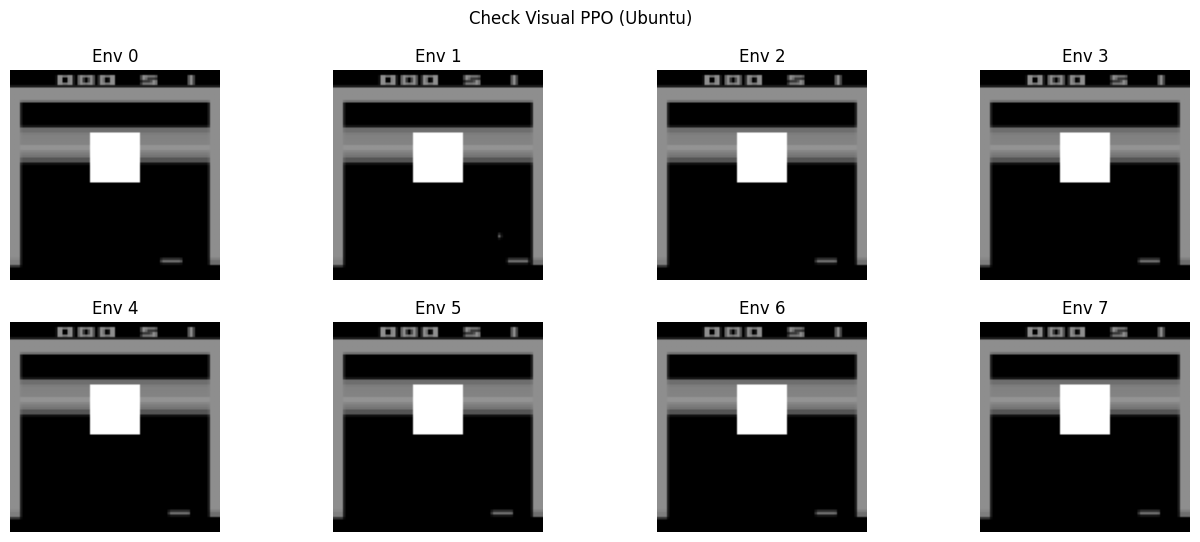

In [19]:
def check_ppo_grid():
    env = make_ppo_multiprocess_env(
        n_envs=8, with_blur=True, change="white_patch", zone="top", log_dir=None
    )
    obs = env.reset()
    # Avança um pouco
    for _ in range(20):
        obs, _, _, _ = env.step([1] * 8)

    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    axes = axes.flatten()
    for i in range(8):
        axes[i].imshow(obs[i, 3, :, :], cmap="gray")
        axes[i].axis("off")
        axes[i].set_title(f"Env {i}")
    plt.suptitle("Check Visual PPO (Ubuntu)")
    plt.show()
    env.close()


check_ppo_grid()

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


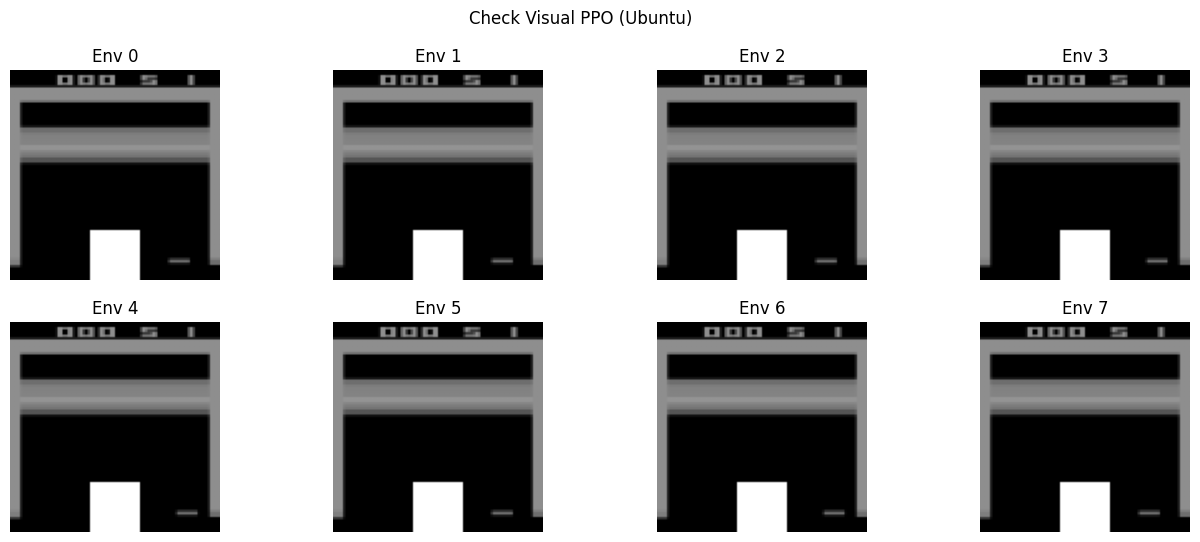

In [20]:
def check_ppo_grid():
    env = make_ppo_multiprocess_env(
        n_envs=8, with_blur=True, change="white_patch", zone="bottom", log_dir=None
    )
    obs = env.reset()
    # Avança um pouco
    for _ in range(20):
        obs, _, _, _ = env.step([1] * 8)

    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    axes = axes.flatten()
    for i in range(8):
        axes[i].imshow(obs[i, 3, :, :], cmap="gray")
        axes[i].axis("off")
        axes[i].set_title(f"Env {i}")
    plt.suptitle("Check Visual PPO (Ubuntu)")
    plt.show()
    env.close()


check_ppo_grid()

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


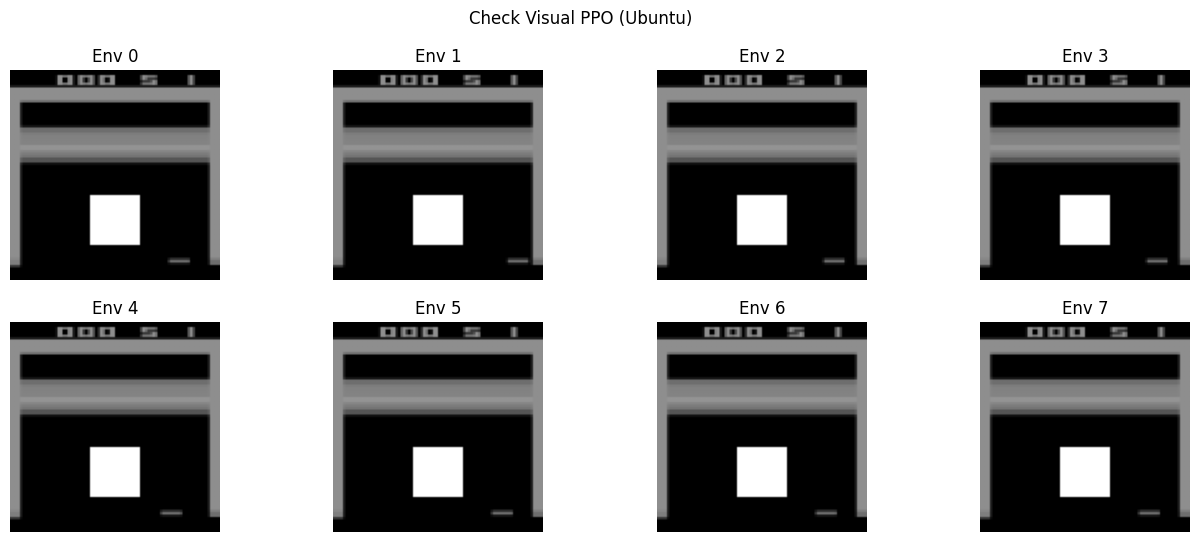

In [21]:
def check_ppo_grid():
    env = make_ppo_multiprocess_env(
        n_envs=8, with_blur=True, change="white_patch", zone="middle", log_dir=None
    )
    obs = env.reset()
    # Avança um pouco
    for _ in range(20):
        obs, _, _, _ = env.step([1] * 8)

    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    axes = axes.flatten()
    for i in range(8):
        axes[i].imshow(obs[i, 3, :, :], cmap="gray")
        axes[i].axis("off")
        axes[i].set_title(f"Env {i}")
    plt.suptitle("Check Visual PPO (Ubuntu)")
    plt.show()
    env.close()


check_ppo_grid()

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


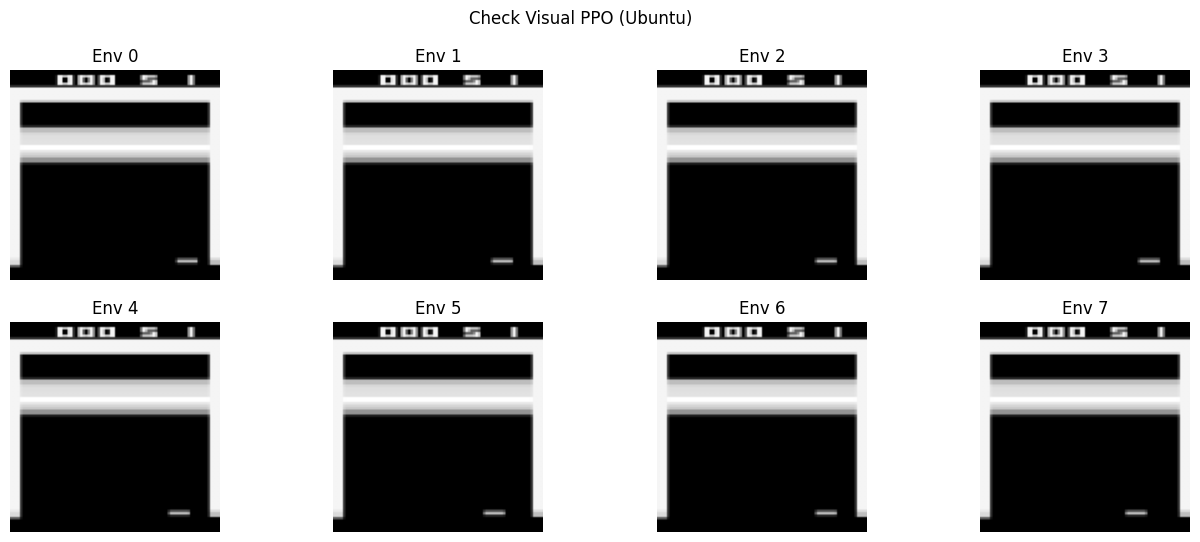

In [22]:
def check_ppo_grid():
    env = make_ppo_multiprocess_env(
        n_envs=8, with_blur=False, change="white_patch", zone="top", log_dir=None
    )
    obs = env.reset()
    # Avança um pouco
    for _ in range(20):
        obs, _, _, _ = env.step([1] * 8)

    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    axes = axes.flatten()
    for i in range(8):
        axes[i].imshow(obs[i, 3, :, :], cmap="gray")
        axes[i].axis("off")
        axes[i].set_title(f"Env {i}")
    plt.suptitle("Check Visual PPO (Ubuntu)")
    plt.show()
    env.close()


check_ppo_grid()

In [23]:
# --- CONFIGURAÇÃO ---
n_envs = 8  # Use o número de núcleos físicos do seu PC
steps_total = 3_000_000  # 3 Milhões de frames (No PPO isso é muito rápido)

experimentos = [
    ("ppo_breakout_normal", False, "middle"),
    ("ppo_breakout_zone_top", True, "top"),
    ("ppo_breakout_zone_middle", True, "middle"),
    ("ppo_breakout_zone_bottom", True, "bottom"),
]

print(f"--- INICIANDO PPO NO UBUNTU ({n_envs} envs paralelos) ---")

for nome_modelo, usar_blur, zona in experimentos:
    start_time = time.time()

    # Configura pastinhas
    suffix = "normal" if not usar_blur else f"hipotese_{zona}"
    log_folder = f"./logs_ppo_{suffix}/"
    tb_log = f"./tb_logs_ppo_{suffix}/"

    print(f"\n>>> TREINANDO: {nome_modelo.upper()}")

    # Cria Ambiente
    env = make_ppo_multiprocess_env(
        n_envs=n_envs,
        with_blur=usar_blur,
        change="white_patch",
        zone=zona,
        log_dir=log_folder,
    )

    # Define Modelo
    model = PPO(
        "CnnPolicy",
        env,
        verbose=1,
        learning_rate=2.5e-4,
        n_steps=128,  # Buffer: 128 * 8 = 1024
        batch_size=256,
        n_epochs=4,
        clip_range=0.1,
        ent_coef=0.01,  # Entropia vital para não travar
        vf_coef=0.5,
        device="auto",  # Usa GPU se tiver, senão CPU
    )

    # Treina
    try:
        model.learn(total_timesteps=steps_total)
        model.save(nome_modelo)
        print(f"--> Salvo: {nome_modelo}.zip")
    except KeyboardInterrupt:
        print("Interrompido pelo usuário, salvando progresso...")
        model.save(nome_modelo + "_interrompido")
    finally:
        env.close()
        elapsed = (time.time() - start_time) / 60
        print(f"--> Tempo: {elapsed:.1f} minutos")

print("\n--- FIM ---")

--- INICIANDO PPO NO UBUNTU (8 envs paralelos) ---

>>> TREINANDO: PPO_BREAKOUT_NORMAL


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
/home/hartb/Estudos/BlurRL/venv/lib/python3.11/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunc

Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 128      |
|    ep_rew_mean     | 0        |
| time/              |          |
|    fps             | 988      |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 1024     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 177          |
|    ep_rew_mean          | 1.14         |
| time/                   |              |
|    fps                  | 545          |
|    iterations           | 2            |
|    time_elapsed         | 3            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0021352796 |
|    clip_fraction        | 0.0459       |
|    clip_range           | 0.1          |
|    entropy_loss         | -1.38        |
|    explained_variance   | -0.035       

BrokenPipeError: [Errno 32] Broken pipe

In [ ]:
# print("--- Iniciando Treino SEM Blur ---")
# env_normal = make_training_env(with_blur=False, change = 'white_patch', log_dir=log_dir_clean)
# # model_normal = DQN("CnnPolicy", env_normal, verbose=1, buffer_size=50_000, learning_starts=10_000, train_freq=4) 
# model_normal = DQN("CnnPolicy", 
#     env_normal, 
#     verbose=1,buffer_size=100_000,  
#     optimize_memory_usage=False,
#     learning_starts=50_000,
#     learning_rate=1e-4,
#     batch_size=32,
#     exploration_fraction=0.1,
#     exploration_final_eps=0.01,
#     train_freq=4,
#     target_update_interval=1000,
#     gradient_steps=1)

# model_normal.learn(total_timesteps=steps) # Baixo para teste rápido
# model_normal.save("dqn_breakout_normal")
# env_normal.close()

In [ ]:
# # Configuração
# steps_por_zona = steps  # Ajuste conforme seu tempo disponível
# zonas = ['top', 'middle', 'bottom']

# for zona in zonas:
#     print(f"\n=============================================")
#     print(f" INICIANDO TREINO: ZONA {zona.upper()}")
#     print(f"=============================================")
    
#     # Define diretório de log específico para não misturar
#     log_dir = f"./logs_hipotese_{zona}/"
    
#     # Cria ambiente na zona específica
#     env = make_training_env(with_blur=True, change='white_patch', zone=zona, log_dir=log_dir)
    
#     # Cria Modelo DQN (Configuração Otimizada que definimos antes)
#     model = DQN(
#         "CnnPolicy", 
#         env, 
#         verbose=1,buffer_size=100_000,
#         optimize_memory_usage=False,
#         learning_starts=50_000,
#         learning_rate=1e-4,
#         batch_size=32,
#         exploration_fraction=0.1,
#         exploration_final_eps=0.01,
#         train_freq=4,
#         target_update_interval=1000,
#         gradient_steps=1
#         )
    
#     # Treina
#     model.learn(total_timesteps=steps_por_zona)
    
#     # Salva com nome distinto
#     model.save(f"dqn_breakout_zone_{zona}")
    
#     env.close()
#     print(f"Modelo da zona {zona} salvo com sucesso!")

# print("\n--- Todos os experimentos finalizados ---")

In [ ]:
def record_video(model, name_prefix, with_blur, change='white_patch', zone='middle', n_episodes=1, max_steps=3000):
    video_folder = "./videos/"
    os.makedirs(video_folder, exist_ok=True)
    
    print(f"--- Gravando {name_prefix} [Zona: {zone}] (Max {max_steps} steps) ---")

    # Coordenadas das zonas (Devem ser IDÊNTICAS ao treino)
    presets = {
        # ZONA 1: TIJOLOS (Y=22)
        # Cobre a maioria das linhas coloridas.
        'top':    (27, 22, 30, 30), 

        # ZONA 2: TRAJETÓRIA/VAZIO (Y=48)
        # Fica entre os tijolos e o paddle. Onde a bola corre livre.
        'middle': (27, 48, 30, 30), 

        # ZONA 3: PADDLE/AGENTE (Y=54)
        # Vai do pixel 54 até 84 (fim da tela). Cobre o agente totalmente.
        'bottom': (27, 54, 30, 30)  
    }
    region = presets.get(zone, (27, 40, 30, 30))

    def _create_video_env():
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        env = FireResetEnv(env)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # Aplica a mancha na zona correta
        if change == 'white_patch':
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=region)
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=region, ksize=21)
        
        env = gym.wrappers.RecordVideo(
            env, 
            video_folder=video_folder, 
            name_prefix=name_prefix,
            episode_trigger=lambda x: True,
            disable_logger=True
        )
        
        env = GrayscaleWrapper(env)
        return env

    env = DummyVecEnv([_create_video_env])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)

    obs = env.reset()
    episodes_count = 0
    current_steps = 0
    last_lives = 5 
    
    try:
        while episodes_count < n_episodes:
            action, _ = model.predict(obs, deterministic=True)
            
            # --- Anti-Stuck: Força FIRE se ficar parado demais ---
            # (Mantenha sua lógica de vidas ou use um contador de ações repetidas)
            
            obs, rewards, done, infos = env.step(action)
            current_steps += 1
            
            # Checagem de vidas para atualizar last_lives
            for info in infos:
                lives = info.get("lives", 0)
                if lives < last_lives:
                    last_lives = lives
            
            if current_steps > max_steps:
                print(f"ALERTA: Episódio excedeu {max_steps} passos. Forçando parada.")
                done = [True]
            
            for i, d in enumerate(done):
                if d:
                    episodes_count += 1
                    current_steps = 0
                    last_lives = 5
                    score = infos[i].get('episode', {}).get('r', 0)
                    print(f"Episódio {episodes_count} finalizado | Score: {score}")
                    obs = env.reset()
                    
    except KeyboardInterrupt:
        print("Interrompido.")
    finally:
        env.close()
        print(f"Vídeos salvos em {video_folder}")

In [ ]:
if os.path.exists("dqn_breakout_zone_top.zip"):
    print(">>> Carregando Modelo TOP...")
    model_top = DQN.load("dqn_breakout_zone_top")
    
    record_video(
        model=model_top, 
        name_prefix="video_teste_TOP", 
        with_blur=True, 
        change='white_patch', 
        zone='top',  # <--- IMPORTANTE: Mudar para 'top'
        n_episodes=2
    )

>>> Carregando Modelo TOP...
--- Gravando video_teste_TOP [Zona: top] (Max 3000 steps) ---


c:\Users\user\Documents\mestrado\BlurRL\.venv\lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\user\Documents\mestrado\BlurRL\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episódio 1 finalizado | Score: 0
Episódio 2 finalizado | Score: 0
Vídeos salvos em ./videos/


In [ ]:
if os.path.exists("dqn_breakout_zone_middle.zip"): # Ou o nome que você usou antes
    print("\n>>> Carregando Modelo MIDDLE...")
    model_middle = DQN.load("dqn_breakout_zone_middle")
    
    record_video(
        model=model_middle, 
        name_prefix="video_teste_MIDDLE", 
        with_blur=True, 
        change='white_patch', 
        zone='middle', 
        n_episodes=2
    )


>>> Carregando Modelo MIDDLE...
--- Gravando video_teste_MIDDLE [Zona: middle] (Max 3000 steps) ---
ALERTA: Episódio excedeu 3000 passos. Forçando parada.
Episódio 1 finalizado | Score: 0
Episódio 2 finalizado | Score: 0
Vídeos salvos em ./videos/


In [ ]:
record_video(model_blur, "teste_com_blur", with_blur=True, change = 'white_patch', n_episodes=5)

--- Gravando teste_com_blur (Max 3000 steps) ---
ALERTA: Episódio excedeu 3000 passos. Forçando parada.
Episódio 1 finalizado | Score: 0
ALERTA: Episódio excedeu 3000 passos. Forçando parada.
Episódio 2 finalizado | Score: 0
Episódio 3 finalizado | Score: 0
ALERTA: Episódio excedeu 3000 passos. Forçando parada.
Episódio 4 finalizado | Score: 0
ALERTA: Episódio excedeu 3000 passos. Forçando parada.
Episódio 5 finalizado | Score: 0
Vídeos salvos em ./videos/


In [ ]:
record_video(model_normal, "teste_sem_blur", with_blur=False, change = 'white_patch', n_episodes=5, max_steps=100_000)

--- Gravando teste_sem_blur (Max 100000 steps) ---


c:\Users\user\Documents\mestrado\BlurRL\.venv\lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\user\Documents\mestrado\BlurRL\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episódio 1 finalizado | Score: 0
Episódio 2 finalizado | Score: 0
Episódio 3 finalizado | Score: 0
Episódio 4 finalizado | Score: 0
Episódio 5 finalizado | Score: 0
Vídeos salvos em ./videos/
